In [5]:
import numpy as np
from pylab import *
from craco.cardcap import CardcapFile
from astropy.io import fits
import json
import gzip

%matplotlib notebook

In [3]:
ls data/SB41783


SB41783.json.gz  spi64-dp-ball/  spi64-dp-ball-ts32/  spi64-dp-ball-ts32-v3/


In [232]:
f = gzip.open('data/SB41783/SB41783.json.gz', 'rt')
json.load(f)

JSONDecodeError: Extra data: line 7698 column 2 (char 166440)

In [24]:
s = f.read()
s = '[' + s.replace('}{', '},{') + ']'

In [25]:
x = json.loads(s)

In [67]:
len(x)

121

In [68]:
x0 = x[60]

In [69]:
x0.keys()

dict_keys(['antenna_targets', 'antennas', 'beams_direction', 'beams_offsets', 'cycle_period', 'flagged', 'phase_direction', 'polangle', 'polmode', 'sbid', 'scan_id', 'schedulingblock_id', 'sky_frequency', 'target_direction', 'target_name', 'timestamp'])

In [90]:
x0['beams_direction'][0]

[62.085000007145645, -65.7525277531197, 'J2000']

In [105]:
x0['timestamp'] # microseconds since MJD in TAI frame, at the start of the long integration cycle.

5162422827947198

In [106]:
hex(x0['timestamp'])

'0x1257323ad714be'

In [107]:
from astropy.time import Time

In [108]:
Time(x0['timestamp']/1e6/3600/24, format='mjd', scale='tai')

<Time object: scale='tai' format='mjd' value=59750.26421235182>

In [109]:
Time.now().mjd

59752.17106523116

In [198]:
times = Time([d['timestamp']/1e6/3600/24 for d in x], format='mjd', scale='tai')

In [110]:
x0['antennas'].keys()

dict_keys(['ak01', 'ak02', 'ak03', 'ak04', 'ak05', 'ak06', 'ak07', 'ak08', 'ak09', 'ak10', 'ak11', 'ak12', 'ak13', 'ak14', 'ak15', 'ak16', 'ak17', 'ak18', 'ak19', 'ak20', 'ak21', 'ak22', 'ak23', 'ak24', 'ak25', 'ak26', 'ak27', 'ak28', 'ak29', 'ak30', 'ak31', 'ak32', 'ak33', 'ak34', 'ak35', 'ak36'])

In [111]:
ants = x0['antennas']

In [112]:
a = ants['ak01']

In [113]:
a['flagged']

False

In [114]:
a['uvw']

[4824939.287310539,
 1608930.0118868435,
 3842132.865815483,
 4738582.719167067,
 1772577.618627895,
 3877432.4323594766,
 4644004.333117021,
 1939675.2480808252,
 3911721.303203405,
 4540448.923155554,
 2109970.419665782,
 3945000.414741854,
 4427119.594834474,
 2283115.343859326,
 3977269.954080208,
 4303186.710568228,
 2458649.298729527,
 4008529.359728854,
 4710167.451686346,
 1751299.386439276,
 3921473.3078390826,
 4617012.366979232,
 1913590.9724032052,
 3956266.7075742264,
 4515445.853943844,
 2078683.917116741,
 3990050.348151508,
 4404764.537371265,
 2246243.518349483,
 4022824.7904366744,
 4284240.072822206,
 2415836.9222022663,
 4054589.8475321876,
 4153130.6664179945,
 2586918.082374053,
 4085344.5840843096,
 4683336.462215882,
 1726192.4993841217,
 3964504.8751025205,
 4591615.699709578,
 1883963.8192629903,
 3999803.1778890016,
 4491999.744173153,
 2044193.0353778254,
 4034091.3475556727,
 4383865.129081189,
 2206559.5588205196,
 4067370.3189365724,
 4266569.355862471,
 

In [115]:
len(a['uvw'])

108

In [116]:
uvw = np.array(a['uvw'])
uvw.shape =(36,3)

In [176]:
def get_uvw(ants):
    nants = len(ants.keys())
    antnames = sorted(ants.keys())
    uvw = np.zeros((nants, 36, 3))
    for iant,antname in enumerate(antnames):
        u = np.array(ants[antname]['uvw']).reshape(36,3)    
        uvw[iant,:,:] = u
        
    return uvw

In [182]:
ants['ak01']['uvw'][:3]

[4824939.287310539, 1608930.0118868435, 3842132.865815483]

In [181]:
ants['ak36']['uvw'][:3]

[4826151.85956113, 1610774.2202114451, 3839827.5871176897]

In [ ]:
uvw[]

In [177]:
uvw = get_uvw(ants)

In [164]:
all_uvw = np.array([get_uvw(samp['antennas']) for samp in x])
all_ts = np.array([samp['timestamp']/34/3600/1e6 for samp in x])

In [206]:
all_uvw[60,0,0,:]

array([4824939.28731054, 1608930.01188684, 3842132.86581548])

In [207]:
all_uvw[60,1,0,:]

array([4824948.8195462 , 1608901.59518606, 3842132.88848743])

In [208]:
all_uvw[60,1,0,:] - all_uvw[60,0,0,:]

array([ 9.53223567e+00, -2.84167008e+01,  2.26719440e-02])

In [209]:
all_uvw[:,1,0,:] - all_uvw[:,0,0,:]

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.06133034e+01, -2.80302102e+01,  1.94980683e-01],
       [ 1.05948179e+01, -2.80372242e+01,  1.91851295e-01],
       [ 1.05763267e+01, -2.80442259e+01,  1.88727440e-01],
       [ 1.05578300e+01, -2.80512154e+01,  1.85609122e-01],
       [ 1.05393278e+01, -2.80581927e+01,  1.82496337e-01],
       [ 1.05208200e+01, -2.80651578e+01,  1.79389092e-01],
       [ 1.05023067e+01, -2.80721106e+01,  1.76287387e-01],
       [ 1.04837878e+01, -2.80790511e+01,  1.73191222e-01],
       [ 1.04652635e+01, -2.80859794e+01,  1.70100600e-01],
       [ 1.04467336e+01, -2.80928955e+01,  1.67015524e-01],
       [ 1.04281983e+01, -2.80997993e+01,  1.63935994e-01],
       [ 1.04096574e+01, -2.81066908e+01,  1.60862010e-01],
       [ 1.03911111e+01, -2.81135701e+01

In [210]:
all_uvw.shape

(121, 36, 36, 3)

In [211]:
from scipy.interpolate import interp1d

In [216]:
uvwinterp = interp1d(times.value, all_uvw, axis=0)

In [217]:
times[60]

<Time object: scale='tai' format='mjd' value=59750.26421235182>

In [218]:
times[60].value

59750.26421235182

In [220]:
uvwinterp(times[60].value).shape

(36, 36, 3)

In [221]:
u1 = uvwinterp(all_ts[60])
u2 = uvwinterp((all_ts[60] + all_ts[61])/2)

In [170]:
u1[0,0,:] - u1[:,0,:]

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-9.53223567e+00,  2.84167008e+01, -2.26719440e-02],
       [-2.16001660e+01,  2.35120547e+01,  1.81932234e+01],
       [-8.10367390e+00, -2.72479410e+01,  2.23092257e+01],
       [ 2.78658908e+01, -7.54043767e+01, -2.77125755e+00],
       [-1.13206729e+02,  3.97776298e+01,  1.28779468e+02],
       [-8.72675143e+01,  2.51981933e+02,  5.82170142e+00],
       [ 1.10247612e+02,  1.10163027e+02, -1.84595320e+02],
       [ 8.83627418e+01, -2.53152442e+02, -5.38128235e+00],
       [-5.24885720e+01, -2.37061680e+02,  1.68878383e+02],
       [-2.69650836e+02,  8.52518865e+00,  3.39358270e+02],
       [-3.11551663e+02,  1.48673517e+02,  3.32311901e+02],
       [-9.78277511e+01,  5.50913673e+02, -1.10471176e+02],
       [ 1.87220723e+02,  2.49643978e+02, -3.39177723e+02],
       [ 4.57302058e+02, -4.77711090e+02, -3.67856953e+02],
       [ 2.03761843e+02, -7.03702119e+02,  4.39946279e+01],
       [ 7.05580707e+01, -6.87815717e+02

In [171]:
d = np.array([uvwinterp(t) for t in all_ts[5:]])
d.shape


(116, 36, 36, 3)

<IPython.core.display.Javascript object>


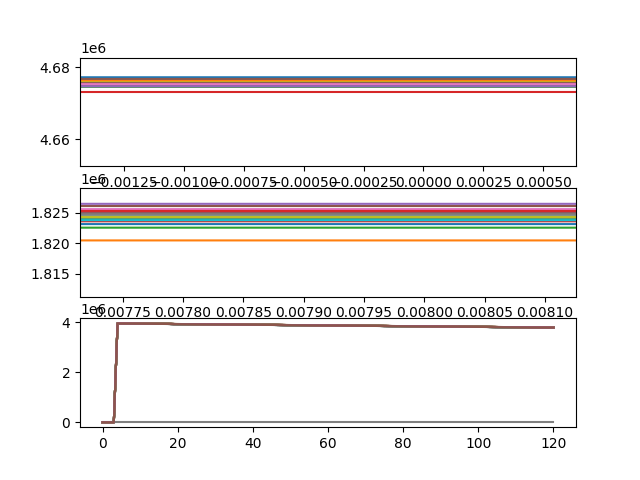

In [191]:
fig, ax = subplots(3,1)
beam = 1
for c in range(3):
    ax[c].plot(all_uvw[:,:,beam,c])

<IPython.core.display.Javascript object>


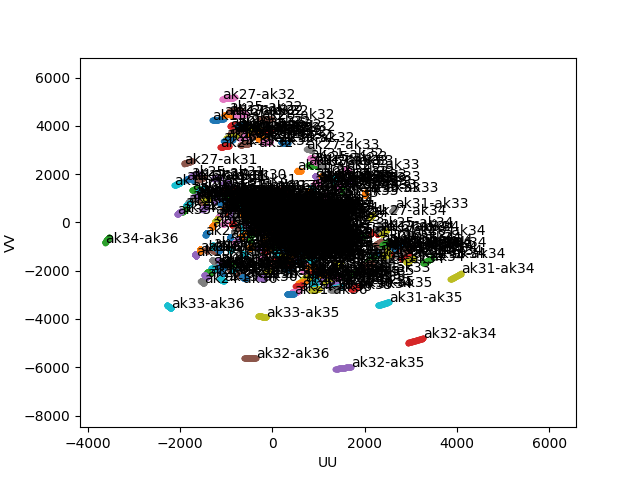

Text(0, 0.5, 'VV')

In [250]:
figure()
nant = 36
for a1 in range(nant):
    for a2 in range(a1, nant):
        uu = d[:,a1,beam,0] - d[:,a2,beam,0]
        vv = d[:,a1,beam,1] - d[:,a2,beam,1]
        uu = all_uvw[30:,a1,beam,0] - all_uvw[30:,a2,beam,0]
        vv = all_uvw[30:,a1,beam,1] - all_uvw[30:,a2,beam,1]
        plot(uu,vv,'.')
        text(uu[0],vv[0],f'ak{a1+1:02d}-ak{a2+1:02d}')
        
xlabel('UU')
ylabel('VV')

In [222]:
x0.keys()

dict_keys(['antenna_targets', 'antennas', 'beams_direction', 'beams_offsets', 'cycle_period', 'flagged', 'phase_direction', 'polangle', 'polmode', 'sbid', 'scan_id', 'schedulingblock_id', 'sky_frequency', 'target_direction', 'target_name', 'timestamp'])

In [223]:
x0['flagged']

False

In [224]:
antnames

['ak01',
 'ak02',
 'ak03',
 'ak04',
 'ak05',
 'ak06',
 'ak07',
 'ak08',
 'ak09',
 'ak10',
 'ak11',
 'ak12',
 'ak13',
 'ak14',
 'ak15',
 'ak16',
 'ak17',
 'ak18',
 'ak19',
 'ak20',
 'ak21',
 'ak22',
 'ak23',
 'ak24',
 'ak25',
 'ak26',
 'ak27',
 'ak28',
 'ak29',
 'ak30',
 'ak31',
 'ak32',
 'ak33',
 'ak34',
 'ak35',
 'ak36']

In [225]:
mainflag = np.array([d['flagged'] for d in x])
antflags = np.array([[d['antennas'][a]['flagged'] for a in antnames] for d in x])

In [226]:
mainflag.shape

(121,)

In [227]:
antflags.shape

(121, 36)

<IPython.core.display.Javascript object>


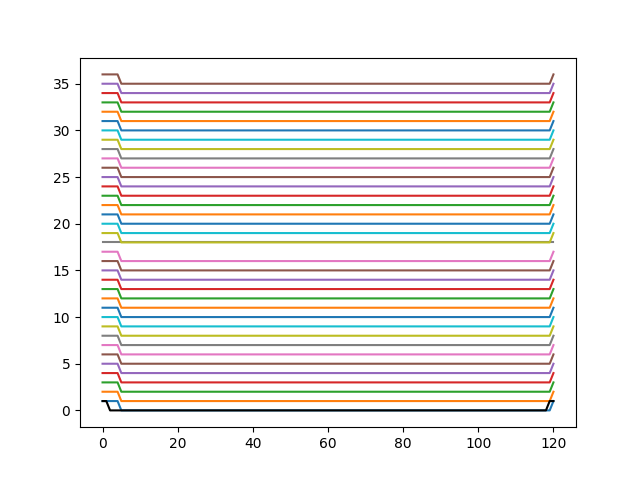

In [231]:
figure()
plot(antflags + np.arange(36))
plot(mainflag, 'k')

In [234]:
t0 = times[0]

In [235]:
t0.iso

'2022-06-20 06:10:10.844'

In [236]:
d0

NameError: name 'd0' is not defined

In [241]:
x0.keys()

dict_keys(['antenna_targets', 'antennas', 'beams_direction', 'beams_offsets', 'cycle_period', 'flagged', 'phase_direction', 'polangle', 'polmode', 'sbid', 'scan_id', 'schedulingblock_id', 'sky_frequency', 'target_direction', 'target_name', 'timestamp'])

In [242]:
x0['sbid']

41783

In [243]:
x0['beams_direction']

[[62.085000007145645, -65.7525277531197, 'J2000'],
 [63.67522064140199, -66.38092969838988, 'J2000'],
 [65.34455355286403, -66.99240022173805, 'J2000'],
 [67.09747169846477, -67.58573753158393, 'J2000'],
 [68.93842362335648, -68.15961733657512, 'J2000'],
 [70.87173985466985, -68.71258786519581, 'J2000'],
 [64.18421631053232, -65.50517039843687, 'J2000'],
 [65.80854978703371, -66.1114547714504, 'J2000'],
 [67.5101831916928, -66.69990358139653, 'J2000'],
 [69.29297944124589, -67.26929650677538, 'J2000'],
 [71.16068260894646, -67.81830056577886, 'J2000'],
 [73.11681990753392, -68.34546776629406, 'J2000'],
 [64.65883325152609, -64.62768482794372, 'J2000'],
 [66.24044462716597, -65.2292408334355, 'J2000'],
 [67.89372745452462, -65.81324624357332, 'J2000'],
 [69.62205436225507, -66.37857478476359, 'J2000'],
 [71.42868165117393, -66.9240000532062, 'J2000'],
 [73.31666749441895, -67.44819382506807, 'J2000'],
 [66.64360153753603, -64.34568759449914, 'J2000'],
 [68.25125866835185, -64.9256626374

In [245]:
x0['target_direction']

[69.77794017406538, -65.93302243738027, 'J2000']

In [246]:
x0['target_name']

'CRAFTCal_beam0_0407-658_beam0'

In [247]:
x0['phase_direction']

[69.77794017406538, -65.93302243738027, 'J2000']

In [249]:
x0['antennas']['ak01'].keys()

dict_keys(['actual_azel', 'actual_pol', 'actual_radec', 'delay', 'delay_rate', 'flagged', 'on_source', 'par_angle', 'uvw'])